# 03 — The Training Loop
**Repo:** [LLM-from-Scratch](https://github.com/sarzara/LLM-from-Scratch) | Section: 01 Neural Networks

## How Does a Network Learn?

Training is a loop of 4 steps, repeated thousands of times:

```
1. FORWARD PASS   → feed input through network → get prediction
2. LOSS           → how wrong was the prediction?
3. BACKWARD PASS  → which weights caused the error? (backpropagation)
4. UPDATE         → nudge each weight in the direction that reduces loss
```

Each complete loop = 1 **epoch**.  
The network improves a tiny bit each epoch — like a student reviewing notes repeatedly.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

# ── Activation functions (from previous notebook) ─────────

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    # needed in backpropagation
    s = sigmoid(x)
    return s * (1 - s)

print('Setup complete')

Setup complete


In [ ]:
# ── Step 1: FORWARD PASS ──────────────────────────────────
# Feed input through every layer and get a prediction

np.random.seed(42)

# simple network: 2 inputs -> 3 hidden neurons -> 1 output
X = np.array([[0.5, 0.8]])   # one input sample, shape (1, 2)
y = np.array([[1.0]])         # correct answer

# random weights at the start (the network knows nothing yet)
W1 = np.random.randn(2, 3) * 0.1   # layer 1: 2 inputs -> 3 hidden
b1 = np.zeros((1, 3))
W2 = np.random.randn(3, 1) * 0.1   # layer 2: 3 hidden -> 1 output
b2 = np.zeros((1, 1))

# forward pass
z1 = X @ W1 + b1        # linear step layer 1,  shape: (1, 3)
a1 = sigmoid(z1)         # activation layer 1,   shape: (1, 3)
z2 = a1 @ W2 + b2       # linear step layer 2,  shape: (1, 1)
a2 = sigmoid(z2)         # prediction (output),  shape: (1, 1)

print('Forward Pass:')
print(f'  Input X:          {X}')
print(f'  Hidden layer z1:  {np.round(z1, 4)}')
print(f'  Hidden layer a1:  {np.round(a1, 4)}')
print(f'  Output z2:        {np.round(z2, 4)}')
print(f'  Prediction a2:    {np.round(a2, 4)}')
print(f'  Correct answer y: {y}')

Forward Pass:
  Input X:          [[0.5 0.8]]
  Hidden layer z1:  [[ 0.1467 -0.0256  0.0137]]
  Hidden layer a1:  [[0.5366 0.4936 0.5034]]
  Output z2:        [[0.099]]
  Prediction a2:    [[0.5247]]
  Correct answer y: [[1.]]


In [ ]:
# ── Step 2: LOSS ──────────────────────────────────────────
# Measure how wrong the prediction was
# MSE = Mean Squared Error = average of (correct - predicted)^2

loss = np.mean((y - a2) ** 2)

print('Loss Calculation:')
print(f'  y (correct):    {y[0][0]:.4f}')
print(f'  a2 (predicted): {a2[0][0]:.4f}')
print(f'  difference:     {(y - a2)[0][0]:.4f}')
print(f'  squared:        {((y - a2)**2)[0][0]:.4f}')
print(f'  MSE loss:       {loss:.4f}')
print()
print('  Goal: make this number as small as possible')
print('  loss = 0 means perfect prediction')

Loss Calculation:
  y (correct):    1.0000
  a2 (predicted): 0.5247
  difference:     0.4753
  squared:        0.2259
  MSE loss:       0.2259

  Goal: make this number as small as possible
  loss = 0 means perfect prediction


In [ ]:
# ── Step 3: BACKWARD PASS (Backpropagation) ───────────────
# Work backwards: figure out how much each weight contributed to the error
# Uses the chain rule from calculus

# output layer gradients
dL_da2 = -2 * (y - a2) / len(y)          # d(loss) / d(a2)
dL_dz2 = dL_da2 * sigmoid_derivative(z2) # d(loss) / d(z2)
dL_dW2 = a1.T @ dL_dz2                   # gradient for W2
dL_db2 = np.sum(dL_dz2, axis=0, keepdims=True)

# hidden layer gradients
dL_da1 = dL_dz2 @ W2.T                   # send gradient back through W2
dL_dz1 = dL_da1 * sigmoid_derivative(z1) # through sigmoid
dL_dW1 = X.T @ dL_dz1                    # gradient for W1
dL_db1 = np.sum(dL_dz1, axis=0, keepdims=True)

print('Backpropagation gradients:')
print(f'  dL/dW2 (blame on W2): {np.round(dL_dW2.T, 6)}')
print(f'  dL/dW1 (blame on W1): {np.round(dL_dW1.T, 6)}')
print()
print('  Positive gradient = weight should decrease')
print('  Negative gradient = weight should increase')

Backpropagation gradients:
  dL/dW2 (blame on W2): [[-0.127205 -0.117008 -0.119337]]
  dL/dW1 (blame on W1): [[-0.004654 -0.007447]
 [-0.002274 -0.003638]
 [ 0.001391  0.002226]]

  Positive gradient = weight should decrease
  Negative gradient = weight should increase


In [ ]:
# ── Step 4: UPDATE WEIGHTS (Gradient Descent) ─────────────
# Nudge each weight slightly in the direction that reduces loss
# Formula: new_weight = old_weight - learning_rate * gradient

lr = 0.1  # learning rate: controls size of each step
          # too large -> overshoots the minimum
          # too small -> takes forever to converge

W2_before = W2.copy()
W1_before = W1.copy()

W2 -= lr * dL_dW2
b2 -= lr * dL_db2
W1 -= lr * dL_dW1
b1 -= lr * dL_db1

# verify loss improved after update
z1_new = X @ W1 + b1
a1_new = sigmoid(z1_new)
z2_new = a1_new @ W2 + b2
a2_new = sigmoid(z2_new)
loss_new = np.mean((y - a2_new) ** 2)

print('Weight Update:')
print(f'  learning rate: {lr}')
print(f'  loss before:   {loss:.6f}')
print(f'  loss after:    {loss_new:.6f}')
print(f'  improved:      {loss_new < loss}')

Weight Update:
  learning rate: 0.1
  loss before:   0.225885
  loss after:    0.215954
  improved:      True


In [ ]:
# ── Full Training Loop ────────────────────────────────────
# Put all 4 steps together and repeat for many epochs

np.random.seed(42)

# data: learn to output 1.0 for input [0.5, 0.8]
X = np.array([[0.5, 0.8]])
y = np.array([[1.0]])

# re-initialize weights
W1 = np.random.randn(2, 3) * 0.1
b1 = np.zeros((1, 3))
W2 = np.random.randn(3, 1) * 0.1
b2 = np.zeros((1, 1))

lr = 0.5
epochs = 1000
loss_history = []

for epoch in range(epochs):

    # STEP 1: forward pass
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)

    # STEP 2: loss
    loss = np.mean((y - a2) ** 2)
    loss_history.append(loss)

    # STEP 3: backward pass
    dL_da2 = -2 * (y - a2) / len(y)
    dL_dz2 = dL_da2 * sigmoid_derivative(z2)
    dL_dW2 = a1.T @ dL_dz2
    dL_db2 = np.sum(dL_dz2, axis=0, keepdims=True)
    dL_da1 = dL_dz2 @ W2.T
    dL_dz1 = dL_da1 * sigmoid_derivative(z1)
    dL_dW1 = X.T @ dL_dz1
    dL_db1 = np.sum(dL_dz1, axis=0, keepdims=True)

    # STEP 4: update weights
    W2 -= lr * dL_dW2
    b2 -= lr * dL_db2
    W1 -= lr * dL_dW1
    b1 -= lr * dL_db1

    if epoch % 200 == 0:
        print(f'Epoch {epoch:4d} | Loss: {loss:.6f} | Prediction: {a2[0][0]:.4f}')

print(f'\nFinal prediction: {a2[0][0]:.4f}  (target: {y[0][0]})')
print(f'Final loss:       {loss:.6f}')

Epoch    0 | Loss: 0.225885 | Prediction: 0.5247
Epoch  200 | Loss: 0.001298 | Prediction: 0.9640
Epoch  400 | Loss: 0.000593 | Prediction: 0.9756
Epoch  600 | Loss: 0.000378 | Prediction: 0.9806
Epoch  800 | Loss: 0.000275 | Prediction: 0.9834

Final prediction: 0.9853  (target: 1.0)
Final loss:       0.000215


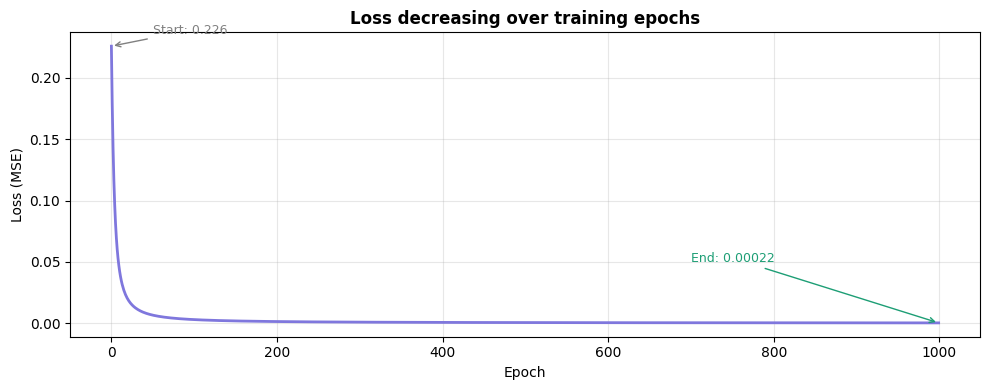

Loss curve saved!


In [ ]:
# ── Plot the loss curve ───────────────────────────────────

plt.figure(figsize=(10, 4))
plt.plot(loss_history, color='#7F77DD', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Loss decreasing over training epochs', fontweight='bold')
plt.grid(True, alpha=0.3)

# mark key points
plt.annotate(f'Start: {loss_history[0]:.3f}',
             xy=(0, loss_history[0]),
             xytext=(50, loss_history[0] + 0.01),
             arrowprops=dict(arrowstyle='->', color='gray'),
             color='gray', fontsize=9)

plt.annotate(f'End: {loss_history[-1]:.5f}',
             xy=(len(loss_history)-1, loss_history[-1]),
             xytext=(700, 0.05),
             arrowprops=dict(arrowstyle='->', color='#1D9E75'),
             color='#1D9E75', fontsize=9)

plt.tight_layout()
plt.savefig('loss_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print('Loss curve saved!')

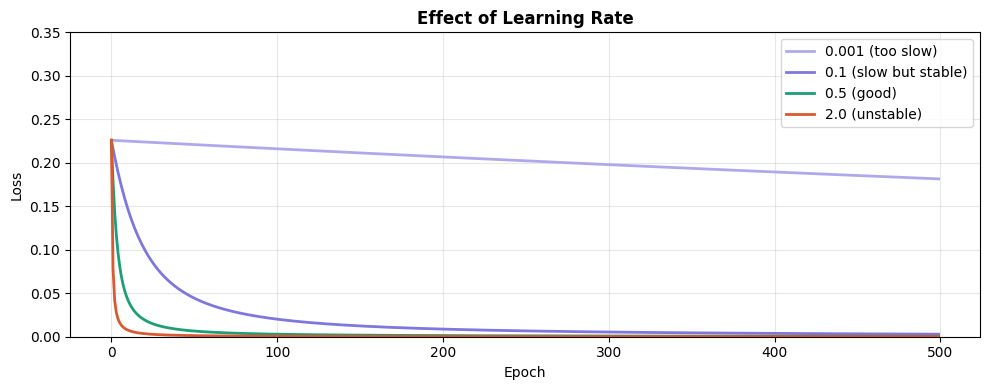

Observations:
  lr=0.001 -> converges very slowly
  lr=0.1   -> converges steadily
  lr=0.5   -> converges faster
  lr=2.0   -> unstable, loss bounces around


In [ ]:
# ── Effect of Learning Rate ───────────────────────────────
# Learning rate is one of the most important hyperparameters

def train(lr, epochs=500):
    np.random.seed(42)
    W1 = np.random.randn(2, 3) * 0.1
    b1 = np.zeros((1, 3))
    W2 = np.random.randn(3, 1) * 0.1
    b2 = np.zeros((1, 1))
    losses = []
    for _ in range(epochs):
        z1 = X @ W1 + b1; a1 = sigmoid(z1)
        z2 = a1 @ W2 + b2; a2 = sigmoid(z2)
        loss = np.mean((y - a2) ** 2)
        losses.append(loss)
        dL_da2 = -2*(y-a2)/len(y); dL_dz2 = dL_da2*sigmoid_derivative(z2)
        dL_dW2 = a1.T@dL_dz2; dL_db2 = np.sum(dL_dz2, axis=0, keepdims=True)
        dL_da1 = dL_dz2@W2.T; dL_dz1 = dL_da1*sigmoid_derivative(z1)
        dL_dW1 = X.T@dL_dz1; dL_db1 = np.sum(dL_dz1, axis=0, keepdims=True)
        W2 -= lr*dL_dW2; b2 -= lr*dL_db2
        W1 -= lr*dL_dW1; b1 -= lr*dL_db1
    return losses

learning_rates = [0.001, 0.1, 0.5, 2.0]
colors = ['#AFA9EC', '#7F77DD', '#1D9E75', '#D85A30']
labels = ['0.001 (too slow)', '0.1 (slow but stable)', '0.5 (good)', '2.0 (unstable)']

plt.figure(figsize=(10, 4))
for lr, color, label in zip(learning_rates, colors, labels):
    losses = train(lr)
    plt.plot(losses, color=color, linewidth=2, label=label)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Effect of Learning Rate', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 0.35)
plt.tight_layout()
plt.savefig('learning_rates.png', dpi=120, bbox_inches='tight')
plt.show()

print('Observations:')
print('  lr=0.001 -> converges very slowly')
print('  lr=0.1   -> converges steadily')
print('  lr=0.5   -> converges faster')
print('  lr=2.0   -> unstable, loss bounces around')

The training loop is the engine of all neural networks:

```
for each epoch:
    prediction  = forward_pass(X, weights)     # step 1
    loss        = compute_loss(prediction, y)  # step 2  
    gradients   = backward_pass(loss)          # step 3
    weights    -= learning_rate * gradients    # step 4
```

**Key concepts:**
- **Loss** measures how wrong the prediction is — we want to minimize it
- **Gradient** tells us which direction to move each weight
- **Learning rate** controls step size — not too big, not too small
- **Epoch** = one full pass through all training data